In [2]:
from pathlib import Path
import yaml
import numpy as np
from torch.utils.data import DataLoader
import wandb
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss
from torch.utils.data import random_split, DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint
from tqdm import tqdm

from sklearn.metrics import roc_curve, auc, precision_score, recall_score
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate

import os
import torch
import sys

sys.path.append("/home/erogullari/Workspace/cav-disentanglement")

In [3]:
# filename = Path("/home/erogullari/Workspace/cav-disentanglement/configs/dataset/celeba.yaml")
filename = Path("/home/erogullari/Workspace/cav-disentanglement/configs/dataset/celeba_attacked.yaml")
device = "cuda"

with open(filename, "r") as fp:
    config = OmegaConf.load(fp)

In [4]:
dataset = instantiate(config)
len(dataset)

20438

In [5]:
concept_names = dataset.get_concept_names()
for i, name in enumerate(concept_names):
    print(f"Concept {i}: {name}")

Concept 0: 5_o_Clock_Shadow
Concept 1: Arched_Eyebrows
Concept 2: Attractive
Concept 3: Bags_Under_Eyes
Concept 4: Bald
Concept 5: Bangs
Concept 6: Big_Lips
Concept 7: Big_Nose
Concept 8: Black_Hair
Concept 9: Blond_Hair
Concept 10: Blurry
Concept 11: Brown_Hair
Concept 12: Bushy_Eyebrows
Concept 13: Chubby
Concept 14: Double_Chin
Concept 15: Eyeglasses
Concept 16: Goatee
Concept 17: Gray_Hair
Concept 18: Heavy_Makeup
Concept 19: High_Cheekbones
Concept 20: Male
Concept 21: Mouth_Slightly_Open
Concept 22: Mustache
Concept 23: Narrow_Eyes
Concept 24: No_Beard
Concept 25: Oval_Face
Concept 26: Pale_Skin
Concept 27: Pointy_Nose
Concept 28: Receding_Hairline
Concept 29: Rosy_Cheeks
Concept 30: Sideburns
Concept 31: Smiling
Concept 32: Straight_Hair
Concept 33: Wavy_Hair
Concept 34: Wearing_Earrings
Concept 35: Wearing_Hat
Concept 36: Wearing_Lipstick
Concept 37: Wearing_Necklace
Concept 38: Wearing_Necktie
Concept 39: Young
Concept 40: timestamp
Concept 41: box


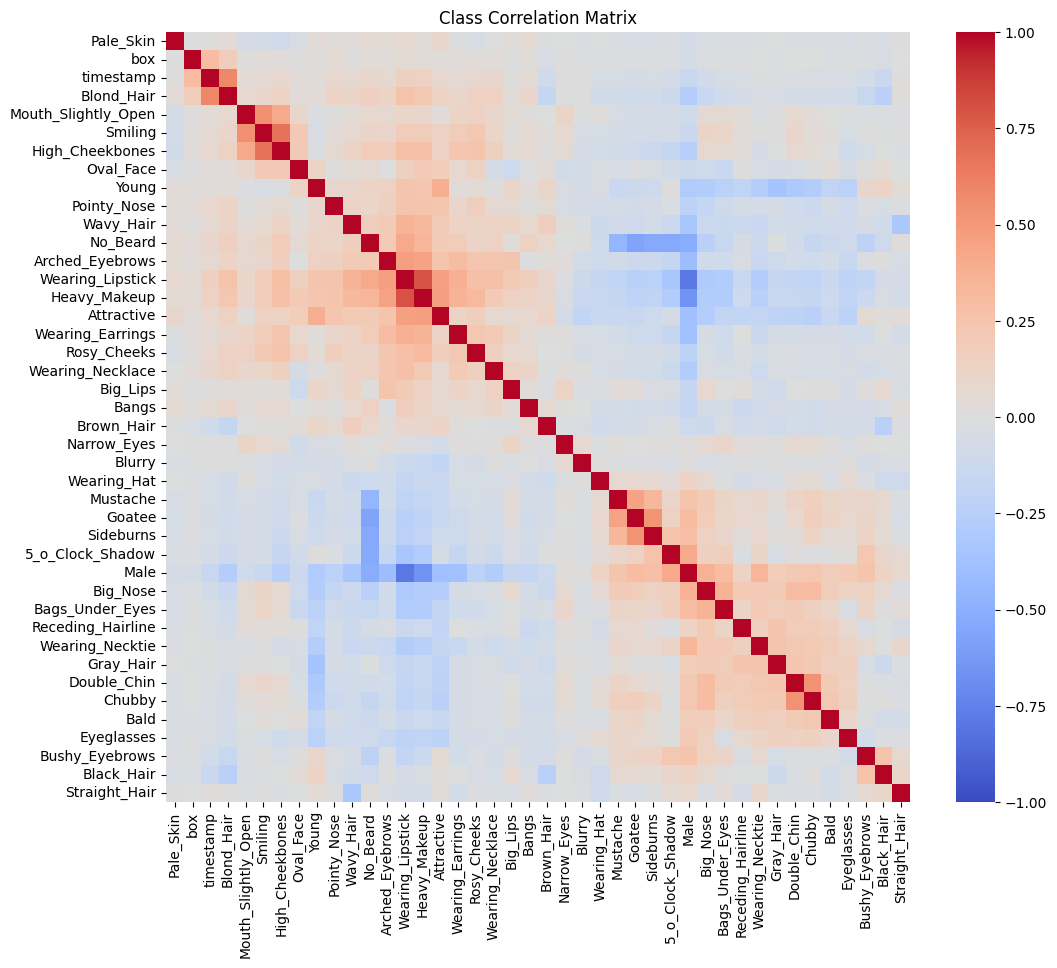

In [6]:
from utils.visualizations import visualize_sim_matrix

concept_names = dataset.get_concept_names()
labels = dataset.get_labels()
mean_centered = labels - labels.mean(dim=0, keepdim=True)
cov_matrix = mean_centered.T @ mean_centered / (labels.shape[0] - 1)
std_dev = labels.std(dim=0, keepdim=True)
correlation_matrix = cov_matrix / (std_dev.T @ std_dev)
visualize_sim_matrix(correlation_matrix, concept_names, title="Class Correlation Matrix")

In [7]:
from models import get_lenet5, get_resnet18, get_simplenet, get_vgg16, get_vit_b_16, get_vit_b_32

in_channels = 3
input_size = config.image_size
model_name = "vit_b_32"

model = get_vit_b_32(n_class=dataset.num_classes, pretrained=True).to(device)

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from torchmetrics import Precision, Recall, F1Score, Accuracy

class ElementClassifier(pl.LightningModule):
    def __init__(self, model, num_classes, learning_rate=1e-3):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        self.loss = CrossEntropyLoss()
        self.optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate)
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.5)
        
        # Multi-label metrics
        self.accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = Precision(task="multiclass", num_classes=num_classes, average="macro")
        self.recall = Recall(task="multiclass", num_classes=num_classes, average="macro")
        self.f1 = F1Score(task="multiclass", num_classes=num_classes, average="macro")
        
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss(logits, y.long())
        preds = torch.argmax(logits, dim=1)
        self.log("train_precision", self.precision(preds, y))
        self.log("train_recall", self.recall(preds, y))
        self.log("train_f1", self.f1(preds, y))
        self.log("train_accuracy", self.accuracy(preds, y))
        self.log("train_loss", loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss(logits, y.long())
        preds = torch.argmax(logits, dim=1)
        
        self.log("val_loss", loss)
        self.log("val_precision", self.precision(preds, y))
        self.log("val_recall", self.recall(preds, y))
        self.log("val_f1", self.f1(preds, y))
        self.log("val_accuracy", self.accuracy(preds, y))
    
    def configure_optimizers(self):
        return {
            "optimizer": self.optimizer,
            "lr_scheduler": {
                "scheduler": self.scheduler,
                "interval": "epoch",  # or "step"
                "frequency": 1,
            },
        }


## Train

In [8]:
from dotenv import load_dotenv

load_dotenv()

WANDB_API_KEY = os.getenv("WANDB_API_KEY")
wandb_project_name = "elements-training-1"

wandb_logger = WandbLogger(
    project=wandb_project_name,
    # api_key=WANDB_API_KEY,
    name=f"{model_name}-celeba_attacked"
)

In [9]:
# Create checkpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints",
    filename=f"{model_name}" + "-celeba_attacked-{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    mode="min",
    save_top_k=3,
    verbose=True
)

lightning_model = ElementClassifier(model, num_classes=dataset.num_classes, learning_rate=0.001)
trainer = pl.Trainer(
    max_epochs=20,
    accelerator="gpu",
    devices=1,
    logger=wandb_logger,
    callbacks=[checkpoint_callback]
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [10]:
# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Train size: 16350, Val size: 4088


In [11]:
trainer.fit(lightning_model, train_loader, val_loader)

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#t

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/erogullari/Workspace/cav-disentanglement/notebooks/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | VisionTransformer   | 87.5 M | train
1 | loss      | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1        | MulticlassF1Score   | 0      | train
----------------------------------------------------------
87.5 M    Trainable params
0         Non-trainable params
87.5 M    Total params
349.828   Total estimated model params size (MB)
163       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


...

Epoch 18: 100%|██████████| 511/511 [02:02<00:00,  4.16it/s, v_num=64ob]

Epoch 18, global step 9709: 'val_loss' was not in top 3


Epoch 19: 100%|██████████| 511/511 [02:02<00:00,  4.17it/s, v_num=64ob]

Epoch 19, global step 10220: 'val_loss' was not in top 3
`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 511/511 [02:02<00:00,  4.17it/s, v_num=64ob]


## Eval

In [9]:
def save_classifier(classifier, model_name, ds_name):
    save_path = f"/media/erogullari/checkpoints/checkpoint_{model_name}_{ds_name}.pth"
    torch.save(classifier.model.state_dict(), save_path)
    print(f"File saved to {save_path}")

# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
_, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Val size: {len(val_dataset)}")
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Val size: 4088


In [10]:
ckpt_path = "checkpoints/vit_b_32-celeba_attacked-epoch=06-val_loss=0.21.ckpt"
backbone = get_vit_b_32(n_class=dataset.num_classes, pretrained=False).to(device)
classifier = ElementClassifier.load_from_checkpoint(ckpt_path, model=backbone, num_classes=2)
classifier.eval().cpu()

ElementClassifier(
  (model): VisionTransformer(
    (conv_proj): Sequential(
      (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
    )
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0

100%|██████████| 128/128 [00:16<00:00,  7.61it/s]


Accuracy: 0.9161
Precision: 0.7295
Recall: 0.7143
F1 Score: 0.7218
AUC: 0.9535
Confusion Matrix:
[[3300  165]
 [ 178  445]]
ROC AUC: 0.9535


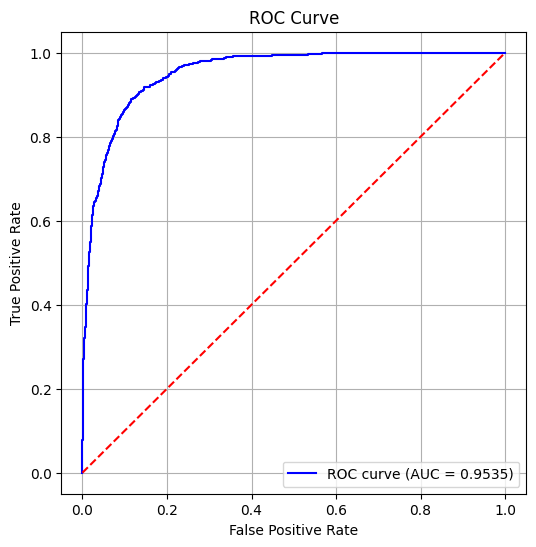

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix

classifier.eval().to(device)
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(val_loader):
        x = x.to(device)
        logits = classifier(x)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="binary", zero_division=0)
recall = recall_score(all_labels, all_preds, average="binary", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(cm)
print(f"ROC AUC: {roc_auc:.4f}")
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [12]:
save_classifier(classifier, model_name=model_name, ds_name="celeba_attacked")

File saved to /media/erogullari/checkpoints/checkpoint_vit_b_32_celeba_attacked.pth
